# Step 7 : Tuning and Stacking

In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score

from xgboost import XGBClassifier
import joblib
import os

In [30]:
filepath = r'dataset/weekly_btc_2017_2026.csv'
theme_color = ['#36827F','#464D77','#F9DB6D','#F4EDED','#877666'] 

In [31]:
df = pd.read_csv(filepath, index_col= 'Unnamed: 0')
df = df.drop(columns = ['pct_change_1w','pct_change_4w','pct_change_8w'])
df.index = pd.to_datetime(df.index) 
df.sort_index(ascending = True, inplace=True)

In [32]:
df.head(3)

,Sentiment,Open,High,Low,Close,Volume,year,month,quarter,weekno
2017-01-06,0.036157,963.658020,1191.099976,883.943970,902.200989,1762148992,2017,1,1,1
2017-01-13,-0.038909,903.487000,942.723999,755.755981,823.984009,1398173008,2017,1,1,2
2017-01-20,-0.075130,825.142029,917.499023,812.455994,895.026001,819957496,2017,1,1,3


## Target Column Creation

In [34]:
# Return percentage change between the current and a prior element.
df['r1'] = df['Close'].pct_change(periods = 1)

In [35]:
df['r1'].describe()

count    484.000000
mean       0.013562
std        0.095893
min       -0.390115
25%       -0.034383
50%        0.006202
75%        0.063766
max        0.509658
Name: r1, dtype: float64

In [36]:
# Binary classes: uptrend, downtrend based on threshold of +-0.01% change. Neutral changes are dropped.
upper_threshold = 0.0001
lower_threshold = -0.0001

mask = (df['r1'] > upper_threshold) | (df['r1'] < lower_threshold) 

print("Kept:", mask.sum())
print("Dropped neutral:", (~mask).sum())

df = df.loc[mask].copy()
df['label_q'] = (df.loc[mask, 'r1'] > upper_threshold).astype(int) # uptrend is 1 , downtrend is 0

Kept: 483
Dropped neutral: 2


## Feature Engeeneering

In [37]:
EPS = 1e-8

# Compute r1
df['r1'] = df['Close'].pct_change(1) 

# compute lag r1 
for lag in [2,4,8,12]:
    df[f"r1_lag{lag}"] = df['r1'].shift(lag) 

# Compute lag multi-Horizon return then lag 
for k in [2,4,8,12]:
    df[f"r{k}_lag1"] = df["Close"].pct_change(k).shift(1)

# Compute Volatility/momentum on weekly log returns then lag 
for w in [2,4,8,12]:
    df[f"vol_{w}w_lag1"] = df["r1"].rolling(w).std().shift(1)
    df[f"mom_{w}w_lag1"] = df["r1"].rolling(w).mean().shift(1) 

# compute high-low range 
df["hl_range"] = (df["High"] - df["Low"]) / (df["Close"] + EPS)

for w in [2,4,8,12]:
    df[f"hl_range_mean_{w}_lag1"] = df["hl_range"].rolling(w).mean().shift(1)
    df[f"hl_range_std_{w}_lag1"] = df["hl_range"].rolling(w).std().shift(1) 

# ---- Trend ---
for w in [2,4,8,12]:
    ma = df["Close"].rolling(w).mean()
    df[f"close_to_ma_{w}_lag1"] = ((df["Close"] - ma) / (ma + EPS)).shift(1)
    df[f"ma_slope_{w}_lag1"] = ma.diff().shift(1)

# --- Volume ---
df["dollar_volume_lag1"] = (df["Close"] * df["Volume"]).shift(1)
df["volume_change_1_lag1"] = df["Volume"].pct_change().shift(1)

for w in [2,4,8,12]:
    vol_mu = df["Volume"].rolling(w).mean()
    vol_sd = df["Volume"].rolling(w).std()
    
    df[f"vol_ratio_{w}_lag1"] = (df["Volume"] / (vol_mu + EPS)).shift(1)
    df[f"vol_z_{w}_lag1"] = ((df["Volume"] - vol_mu) / (vol_sd + EPS)).shift(1)

# Define RSI function
def rsi_wilder(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

for p in [4,8,12]:
    df[f"RSI_{p}w"] = rsi_wilder(df["Close"], p)
    df[f"RSI_{p}w_lag1"] = df[f"RSI_{p}w"].shift(1)


# sentiment features engineering 
df["sentiment_lag_1"] = df["Sentiment"].shift(1)
df["sentiment_chg_1_lag1"] = df["Sentiment"].diff(1).shift(1)
df["sentiment_chg_2_lag1"] = df["Sentiment"].diff(2).shift(1) 

# rolling sentiment 
for w in [4,8]:
    df[f"s_mean_{w}_lag1"] = df["Sentiment"].rolling(w).mean().shift(1)
    df[f"s_std_{w}_lag1"]  = df["Sentiment"].rolling(w).std().shift(1) 

# extreme sentiment features 
z = (df["Sentiment"] - df["Sentiment"].rolling(8).mean()) / df["Sentiment"].rolling(8).std()
df["sentiment_z8_lag1"] = z.shift(1)

# x momentum features 
df['sentiment_x_momentum_lag1'] = df['sentiment_lag_1'] * df['mom_4w_lag1']
df['rsi_x_sentiment_lag1'] = df['RSI_4w_lag1'] *df['sentiment_lag_1'] 
df['sentiment_x_trend_lag1'] = df['sentiment_lag_1'] * df['close_to_ma_4_lag1']

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 483 entries, 2017-01-13 to 2026-04-17
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sentiment                  483 non-null    float64
 1   Open                       483 non-null    float64
 2   High                       483 non-null    float64
 3   Low                        483 non-null    float64
 4   Close                      483 non-null    float64
 5   Volume                     483 non-null    int64  
 6   year                       483 non-null    int64  
 7   month                      483 non-null    int64  
 8   quarter                    483 non-null    int64  
 9   weekno                     483 non-null    int64  
 10  r1                         482 non-null    float64
 11  label_q                    483 non-null    int64  
 12  r1_lag2                    480 non-null    float64
 13  r1_lag4                    478 

In [40]:
# --- 1) Define columns set for different scenario ---
price_cols = [    
    # --- Returns / momentum ---
    'r1_lag2',
    'r1_lag8',
    'r1_lag12',
    'r4_lag1',

    # --- Volatility ---
    'vol_4w_lag1',
    'mom_4w_lag1',
    'vol_12w_lag1',
    'mom_12w_lag1',
    'hl_range_std_4_lag1',
    'hl_range_std_12_lag1',

    # --- Trend ---
    'close_to_ma_4_lag1',
    'ma_slope_4_lag1',
    'close_to_ma_8_lag1',
    'ma_slope_8_lag1',
    
    # --- Volume ---
    'dollar_volume_lag1',
    'volume_change_1_lag1',
    'vol_z_4_lag1',
    'vol_z_8_lag1',
    'vol_z_12_lag1',
    
    # --- RSI ---
    'RSI_4w_lag1',
    'RSI_8w_lag1',
    'RSI_12w_lag1',

] 

sent_cols = [
     # --- Sentiment ---
    'sentiment_lag_1',
    'sentiment_chg_1_lag1',
    'sentiment_chg_2_lag1',
    's_mean_4_lag1',
    's_std_4_lag1',
    's_mean_8_lag1',
    's_std_8_lag1',
    'sentiment_z8_lag1',
    'sentiment_x_momentum_lag1',
    'rsi_x_sentiment_lag1',
    'sentiment_x_trend_lag1'  
]

X_sets = {
    "price_only": price_cols,
    "sent_only": sent_cols,
    "combined": price_cols + sent_cols,      
} 

### XGBoost Hyperparameter Tuning with Combined Features

In [41]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
import time  

# Prepare data 
df_model = df.copy().sort_index()   # or sort_values("date") if you have a date column
df_model = df_model.dropna(subset=price_cols + sent_cols + ["label_q"])  # simplest

# Prepare combined features data
X_combined = df_model[price_cols + sent_cols]
y_combined = df_model["label_q"].astype(int)

print(f"Combined feature set shape: {X_combined.shape}")
print(f"Target distribution:\n{y_combined.value_counts().sort_index()}")

Combined feature set shape: (470, 33)
Target distribution:
label_q
0    218
1    252
Name: count, dtype: int64


In [42]:
# time series split for cross-validation 
tscv = TimeSeriesSplit(n_splits=5)

# Define parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'n_estimators': [100, 200, 300, 400],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma': [0, 1, 2, 3],
    'min_child_weight': [1, 2, 3],
}

# Create base XGBoost classifier (BINARY classification)
xgb_base = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    verbosity=0
)

# Use RandomizedSearchCV for faster tuning (GridSearch would be too slow)
print("Starting RandomizedSearchCV for XGBoost hyperparameter tuning...")

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,  # Number of combinations to try
    cv=tscv,  # Use TimeSeriesSplit for proper cross-validation
    scoring='balanced_accuracy',  # Primary metric
    n_jobs=-1,  # Use all available cores
    verbose=1,
    random_state=42
)

start_time = time.time()
xgb_search.fit(X_combined, y_combined)
elapsed_time = time.time() - start_time

print(f"\n✓ Hyperparameter tuning completed in {elapsed_time/60:.2f} minutes")
print(f"\nBest parameters: {xgb_search.best_params_}")
print(f"Best balanced accuracy score: {xgb_search.best_score_:.4f}")

Starting RandomizedSearchCV for XGBoost hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ Hyperparameter tuning completed in 0.17 minutes

Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 2, 'colsample_bytree': 0.9}
Best balanced accuracy score: 0.5016


In [43]:
# Display top 10 parameter combinations
results_df = pd.DataFrame(xgb_search.cv_results_)
results_df = results_df[['param_max_depth', 'param_learning_rate', 'param_n_estimators', 
                          'param_subsample', 'param_colsample_bytree', 'param_gamma', 
                          'param_min_child_weight', 'mean_test_score', 'std_test_score']].sort_values(
                          'mean_test_score', ascending=False)

print("Top 10 Parameter Combinations:")
print("="*120)
print(results_df.head(10).to_string(index=False))
print("="*120)


Top 10 Parameter Combinations:
 param_max_depth  param_learning_rate  param_n_estimators  param_subsample  param_colsample_bytree  param_gamma  param_min_child_weight  mean_test_score  std_test_score
               4                 0.01                 200              0.8                     0.9            2                       3         0.501638        0.045474
               3                 0.10                 300              0.7                     0.6            3                       2         0.499890        0.066313
               4                 0.10                 300              0.6                     0.8            3                       1         0.498220        0.052041
               4                 0.15                 100              0.9                     0.8            3                       3         0.497087        0.062290
               7                 0.01                 200              0.7                     0.7            3             

In [44]:
# Train final model with best parameters on full training data
best_xgb = xgb_search.best_estimator_

print("\n" + "="*80)
print("TRAINING FINAL XGBoost MODEL WITH BEST PARAMETERS")
print("="*80)

# Split data for final evaluation
from sklearn.model_selection import train_test_split

# For time series, use temporal split
train_size = int(0.8 * len(X_combined))
X_train_final = X_combined.iloc[:train_size]
y_train_final = y_combined.iloc[:train_size]
X_test_final = X_combined.iloc[train_size:]
y_test_final = y_combined.iloc[train_size:]

# Train on full training set
best_xgb.fit(X_train_final, y_train_final)

# Make predictions
y_pred_final = best_xgb.predict(X_test_final)

print("\n✓ Model Training Complete!")
print(f"Training set size: {X_train_final.shape[0]} samples")
print(f"Test set size: {X_test_final.shape[0]} samples")


TRAINING FINAL XGBoost MODEL WITH BEST PARAMETERS

✓ Model Training Complete!
Training set size: 376 samples
Test set size: 94 samples



FINAL XGBoost MODEL PERFORMANCE (Combined Features)

Test Accuracy: 0.5532
Balanced Accuracy: 0.5678
Macro F1-Score: 0.5025
Weighted F1-Score: 0.4958

Confusion Matrix:
[[41  4]
 [38 11]]

Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.52      0.91      0.66        45
  Uptrend (1)       0.73      0.22      0.34        49

     accuracy                           0.55        94
    macro avg       0.63      0.57      0.50        94
 weighted avg       0.63      0.55      0.50        94



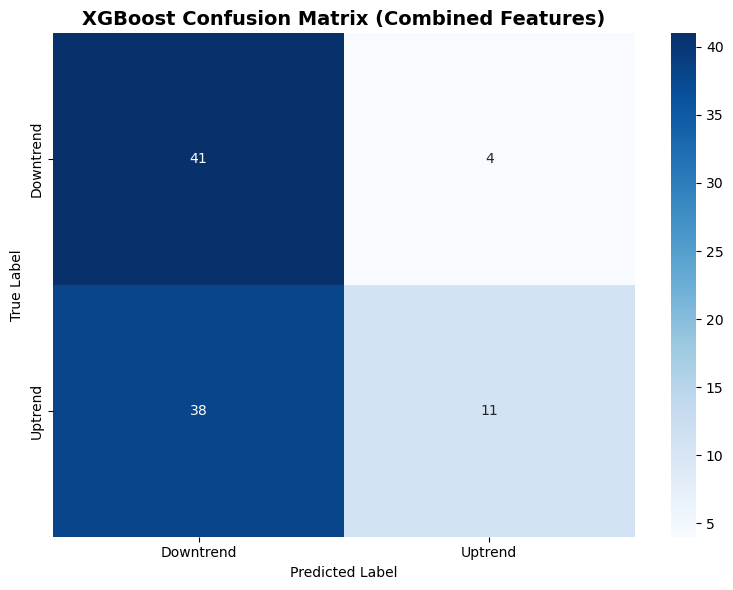

In [45]:
# Evaluate tuned XGBoost model
print("\n" + "="*80)
print("FINAL XGBoost MODEL PERFORMANCE (Combined Features)")
print("="*80)

print(f"\nTest Accuracy: {accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Macro F1-Score: {f1_score(y_test_final, y_pred_final, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test_final, y_pred_final, average='weighted'):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_final, y_pred_final, labels=[0, 1])
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_final, 
                          target_names=['Downtrend (0)', 'Uptrend (1)']))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Downtrend', 'Uptrend'],
            yticklabels=['Downtrend', 'Uptrend'])
plt.title('XGBoost Confusion Matrix (Combined Features)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [71]:
# Save XGboost Best Model
os.makedirs('models', exist_ok=True)
joblib.dump(best_xgb, 'models/best_xgb_model.joblib')
print('Saved best XGBoost model to models/best_xgb_model.joblib')

Saved best XGBoost model to models/best_xgb_model.joblib


## Stacking Ensemble Model
#### Base Learners: LogisticRegression, RandomForest, XGBoost, HistGradientBoost
#### Meta Learner: LogisticRegression

In [52]:
# base model with default parameters for comparison 
logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])


rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        n_jobs=1  # Set to 1 for stacking compatibility
    ))
])

hgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", HistGradientBoostingClassifier(
        random_state=42,
        max_depth=3,
        learning_rate=0.05
    ))
]) 

xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        max_depth=3,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="auc",
        tree_method="hist",
        n_jobs=1  # Set to 1 for stacking compatibility
    ))
])


In [54]:
# ==============================================================================
# STACKING ENSEMBLE IMPLEMENTATION
# ==============================================================================

print("="*80)
print("STACKING ENSEMBLE: Setup & Model Configuration")
print("="*80)

# Ensure models directory exists
os.makedirs('models', exist_ok=True)

# Verify dataset dimensions and class distribution
print(f"\nDataset Summary:")
print(f"  X_combined shape: {X_combined.shape}")
print(f"  y_combined shape: {y_combined.shape}")
print(f"  Class distribution:\n{y_combined.value_counts().sort_index()}")
print(f"  Class proportions:\n{y_combined.value_counts(normalize=True).sort_index()}")


STACKING ENSEMBLE: Setup & Model Configuration

Dataset Summary:
  X_combined shape: (470, 33)
  y_combined shape: (470,)
  Class distribution:
label_q
0    218
1    252
Name: count, dtype: int64
  Class proportions:
label_q
0    0.46383
1    0.53617
Name: proportion, dtype: float64


In [55]:
def build_stacking_classifier(passthrough=True, cv_splits=5):
    """
    Construct StackingClassifier with 4 base learners and LogisticRegression meta-learner.
    
    Parameters:
    -----------
    passthrough : bool
        If True, original features are passed to meta-learner alongside base learner outputs.
        Set False if overfitting is observed.
    cv_splits : int
        Number of splits for cross-validation during stacking.
        Uses StratifiedKFold internally for better class balance.
    
    Returns:
    --------
    sklearn.ensemble.StackingClassifier
        Fitted stacking model ready for training.
    """
    
    # Use existing pipeline definitions (logreg, rf, hgb, xgb from previous cell)
    # Base learner estimators (already wrapped in Pipelines)
    base_estimators = [
        ('rf', rf),
        ('hgb', hgb),
        ('xgb', xgb),
        ('logreg', logreg)
    ]
    
    # Meta-learner: LogisticRegression
    # Use class_weight='balanced' to handle any imbalance
    meta_learner = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
    
    # Create StackingClassifier
    # Note: Using cv as an integer (StratifiedKFold) for internal meta-learner training.
    # While TimeSeriesSplit is more appropriate for time series, StratifiedKFold ensures:
    # - Each fold has balanced class distribution
    # - Compatible partition structure (all samples covered exactly once)
    # The main temporal split is preserved at the outer Train/Test split level
    stacking_clf = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=cv_splits,  # Use integer for StratifiedKFold
        stack_method='predict_proba',  # Use probability predictions
        passthrough=passthrough,  # Include original features to meta-learner
        n_jobs=1  # Set to 1 to avoid nested parallelization issues
    )
    
    return stacking_clf

# Initialize stacking classifier
stacking_model = build_stacking_classifier(passthrough=True, cv_splits=5)

print("\nStackingClassifier Configuration:")
print(f"  Base Learners: {len(stacking_model.estimators)} estimators")
print(f"  Base Estimators: {[name for name, _ in stacking_model.estimators]}")
print(f"  Meta-Learner: LogisticRegression")
print(f"  Stack Method: predict_proba")
print(f"  Passthrough: {stacking_model.passthrough}")
print(f"  Cross-Validation: StratifiedKFold (n_splits={stacking_model.cv}) - for balanced class distribution")
print(f"  Note: Outer train/test split is temporally stratified (TimeSeriesSplit)")
print(f"  Parallel Jobs: {stacking_model.n_jobs} (sequential to avoid nesting conflicts)")



StackingClassifier Configuration:
  Base Learners: 4 estimators
  Base Estimators: ['rf', 'hgb', 'xgb', 'logreg']
  Meta-Learner: LogisticRegression
  Stack Method: predict_proba
  Passthrough: True
  Cross-Validation: StratifiedKFold (n_splits=5) - for balanced class distribution
  Note: Outer train/test split is temporally stratified (TimeSeriesSplit)
  Parallel Jobs: 1 (sequential to avoid nesting conflicts)


In [56]:
def evaluate_model(model, X_test, y_test, model_name="Model", label_names=None):
    """
    Evaluate classification model on test set.
    
    Parameters:
    -----------
    model : sklearn estimator
        Fitted model.
    X_test : array-like
        Test features.
    y_test : array-like
        Test labels.
    model_name : str
        Display name for the model.
    label_names : list
        Names for class labels (e.g., ['Downtrend', 'Uptrend']).
    
    Returns:
    --------
    dict
        Dictionary containing all metrics.
    """
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=np.sort(np.unique(y_test)))
    
    # Get probability predictions for ROC-AUC if available
    try:
        y_proba = model.predict_proba(X_test)
        # For binary classification, calculate ROC-AUC
        if y_proba.shape[1] == 2:
            from sklearn.metrics import roc_auc_score
            roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            roc_auc = None  # Skip for multiclass without OvR specification
    except:
        roc_auc = None
    
    # Print results
    print(f"\n{model_name} Performance (Test Set):")
    print(f"  Accuracy:         {acc:.4f}")
    print(f"  Balanced Accuracy: {balanced_acc:.4f}")
    print(f"  Macro F1-Score:   {macro_f1:.4f}")
    print(f"  Weighted F1-Score: {weighted_f1:.4f}")
    if roc_auc is not None:
        print(f"  ROC-AUC Score:    {roc_auc:.4f}")
    
    print(f"\n  Confusion Matrix:")
    print(f"  {cm}")
    
    print(f"\n  Classification Report:")
    if label_names is None:
        label_names = [f"Class {i}" for i in np.sort(np.unique(y_test))]
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))
    
    # Store metrics in dict
    metrics = {
        'model_name': model_name,
        'accuracy': acc,
        'balanced_accuracy': balanced_acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_proba': y_proba if roc_auc is not None else None
    }
    
    return metrics

# Label names for reporting
LABEL_NAMES = ['Downtrend (0)', 'Uptrend (1)']


In [57]:
print("\n" + "="*80)
print("TRAINING & EVALUATING STACKING ENSEMBLE MODEL")
print("="*80)

# Train stacking model on training set
print("\nTraining StackingClassifier...")
print(f"  Training set size: {X_train_final.shape[0]} samples")
print(f"  Test set size: {X_test_final.shape[0]} samples")
print(f"  Number of features: {X_train_final.shape[1]}")

start_time = time.time()
stacking_model.fit(X_train_final, y_train_final)
stacking_train_time = time.time() - start_time

print(f"✓ Training completed in {stacking_train_time:.2f} seconds")

# Evaluate stacking model
stacking_metrics = evaluate_model(
    stacking_model,
    X_test_final,
    y_test_final,
    model_name="STACKING ENSEMBLE (Meta: LogReg)",
    label_names=LABEL_NAMES
)

print(f"\n" + "="*80)



TRAINING & EVALUATING STACKING ENSEMBLE MODEL

Training StackingClassifier...
  Training set size: 376 samples
  Test set size: 94 samples
  Number of features: 33
✓ Training completed in 6.93 seconds

STACKING ENSEMBLE (Meta: LogReg) Performance (Test Set):
  Accuracy:         0.4787
  Balanced Accuracy: 0.5000
  Macro F1-Score:   0.3237
  Weighted F1-Score: 0.3100
  ROC-AUC Score:    0.5832

  Confusion Matrix:
  [[45  0]
 [49  0]]

  Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.48      1.00      0.65        45
  Uptrend (1)       0.00      0.00      0.00        49

     accuracy                           0.48        94
    macro avg       0.24      0.50      0.32        94
 weighted avg       0.23      0.48      0.31        94




## High Gradient Boosting 
#### As stacking ensemble show that HGBoosting actually perform best, we will try to hypertune this model as well.


In [59]:
# HistGradientBoostingClassifier Hyperparameter Tuning with Combined Features
print("HistGradientBoostingClassifier Hyperparameter Tuning with Combined Features")
print("="*80)
print(f"Combined feature set shape: {X_combined.shape}")
print(f"Target distribution:\n{y_combined.value_counts().sort_index()}")


HistGradientBoostingClassifier Hyperparameter Tuning with Combined Features
Combined feature set shape: (470, 33)
Target distribution:
label_q
0    218
1    252
Name: count, dtype: int64


In [60]:
# Time series split for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Define parameter grid for hyperparameter tuning
histgb_param_grid = {
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.15],
    'max_iter': [100, 200, 300, 400, 500],
    'max_leaf_nodes': [20, 31, 50, 100],
    'min_samples_leaf': [5, 10, 20],
    'l2_regularization': [0.0, 0.01, 0.1, 1.0],
    'max_features': [0.5, 0.7, 1.0],
}

# Create base HistGradientBoostingClassifier
histgb_base = HistGradientBoostingClassifier(
    loss='log_loss',  # Correct for binary classification
    early_stopping=False,
    random_state=42,
    verbose=False,
)

# Use RandomizedSearchCV for faster tuning
print("\nStarting RandomizedSearchCV for HistGradientBoostingClassifier hyperparameter tuning...")
print("This may take a few minutes...\n")

histgb_search = RandomizedSearchCV(
    histgb_base,
    param_distributions=histgb_param_grid,
    n_iter=50,  # Number of combinations to try
    cv=tscv,  # Use TimeSeriesSplit for proper cross-validation
    scoring='balanced_accuracy',  # Primary metric
    n_jobs=-1,  # Use all available cores
    verbose=1,
    random_state=42
)

start_time = time.time()
histgb_search.fit(X_combined, y_combined)
elapsed_time = time.time() - start_time

print(f"\n✓ HistGradientBoosting hyperparameter tuning completed in {elapsed_time/60:.2f} minutes")
print(f"\nBest parameters: {histgb_search.best_params_}")
print(f"Best balanced accuracy score: {histgb_search.best_score_:.4f}")



Starting RandomizedSearchCV for HistGradientBoostingClassifier hyperparameter tuning...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✓ HistGradientBoosting hyperparameter tuning completed in 0.19 minutes

Best parameters: {'min_samples_leaf': 20, 'max_leaf_nodes': 50, 'max_iter': 200, 'max_features': 1.0, 'max_depth': 8, 'learning_rate': 0.001, 'l2_regularization': 0.0}
Best balanced accuracy score: 0.5065


In [61]:
# Display top 10 parameter combinations for HistGradientBoostingClassifier
histgb_results_df = pd.DataFrame(histgb_search.cv_results_)
histgb_results_df = histgb_results_df[['param_max_depth', 'param_learning_rate', 'param_max_iter',
                                        'param_max_leaf_nodes', 'param_min_samples_leaf', 'param_l2_regularization',
                                        'param_max_features',
                                        'mean_test_score', 'std_test_score']].sort_values(
                                        'mean_test_score', ascending=False)

print("Top 10 HistGradientBoosting Parameter Combinations:")
print("="*150)
print(histgb_results_df.head(10).to_string(index=False))
print("="*150)

Top 10 HistGradientBoosting Parameter Combinations:
 param_max_depth  param_learning_rate  param_max_iter  param_max_leaf_nodes  param_min_samples_leaf  param_l2_regularization  param_max_features  mean_test_score  std_test_score
               8                0.001             200                    50                      20                     0.00                 1.0         0.506451        0.027572
               5                0.001             100                   100                       5                     0.00                 0.5         0.500000        0.000000
               7                0.001             100                   100                      20                     0.01                 0.5         0.500000        0.000000
               4                0.050             400                    31                       5                     0.00                 0.7         0.499914        0.029934
               7                0.050             300     

In [64]:
# Train final model with best parameters on full training data
best_hgb = histgb_search.best_estimator_

print("\n" + "="*80)
print("TRAINING FINAL HistGradientBoosting MODEL WITH BEST PARAMETERS")
print("="*80)

# Split data for final evaluation
from sklearn.model_selection import train_test_split

# For time series, use temporal split
train_size = int(0.8 * len(X_combined))
X_train_final = X_combined.iloc[:train_size]
y_train_final = y_combined.iloc[:train_size]
X_test_final = X_combined.iloc[train_size:]
y_test_final = y_combined.iloc[train_size:]

# Train on full training set
best_hgb.fit(X_train_final, y_train_final)

# Make predictions
y_pred_final = best_hgb.predict(X_test_final)

print("\n✓ Model Training Complete!")
print(f"Training set size: {X_train_final.shape[0]} samples")
print(f"Test set size: {X_test_final.shape[0]} samples")


TRAINING FINAL HistGradientBoosting MODEL WITH BEST PARAMETERS

✓ Model Training Complete!
Training set size: 376 samples
Test set size: 94 samples



FINAL HistGradientBoosting MODEL PERFORMANCE (Combined Features)

Test Accuracy: 0.5213
Balanced Accuracy: 0.5082
Macro F1-Score: 0.4629
Weighted F1-Score: 0.4704

Confusion Matrix:
[[ 9 36]
 [ 9 40]]

Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.50      0.20      0.29        45
  Uptrend (1)       0.53      0.82      0.64        49

     accuracy                           0.52        94
    macro avg       0.51      0.51      0.46        94
 weighted avg       0.51      0.52      0.47        94



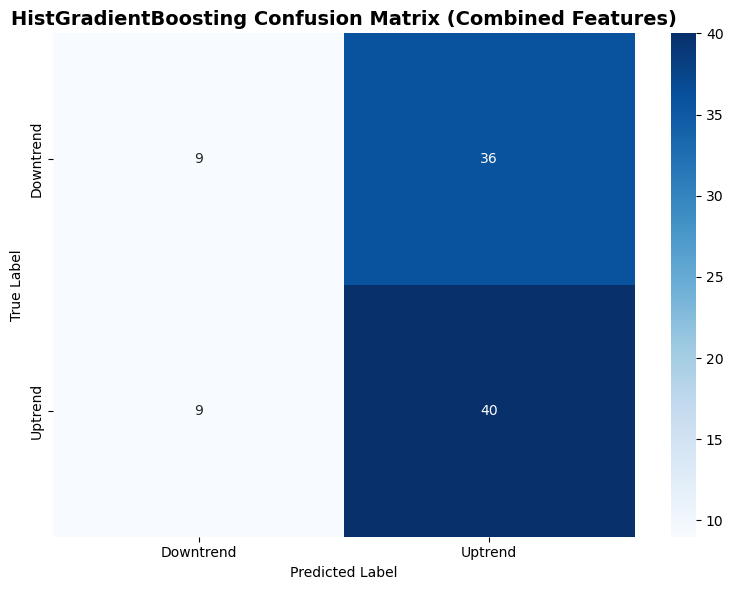

In [65]:
# Evaluate tuned HistGradientBoosting model
print("\n" + "="*80)
print("FINAL HistGradientBoosting MODEL PERFORMANCE (Combined Features)")
print("="*80)

print(f"\nTest Accuracy: {accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_final, y_pred_final):.4f}")
print(f"Macro F1-Score: {f1_score(y_test_final, y_pred_final, average='macro'):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test_final, y_pred_final, average='weighted'):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_final, y_pred_final, labels=[0, 1])
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_final, 
                          target_names=['Downtrend (0)', 'Uptrend (1)']))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Downtrend', 'Uptrend'],
            yticklabels=['Downtrend', 'Uptrend'])
plt.title('HistGradientBoosting Confusion Matrix (Combined Features)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Stacking using Best_XGB + Best_HGB model
#### As stacking ensemble using the tuned XGB and HGB model to see how they perform

In [68]:
# Weighted fusion alpha search between best_xgb and best_hgb
import numpy as np
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
import joblib, os

# Create temporal validation split from training set (last 20% of training as val)
val_size = max(1, int(0.2 * len(X_train_final)))
X_sub_train = X_train_final.iloc[:-val_size]
y_sub_train = y_train_final.iloc[:-val_size]
X_val = X_train_final.iloc[-val_size:]
y_val = y_train_final.iloc[-val_size:]

# Refit clones of base models on sub-train for tuning
xgb_clone = clone(best_xgb)
hgb_clone = clone(best_hgb)
xgb_clone.fit(X_sub_train, y_sub_train)
hgb_clone.fit(X_sub_train, y_sub_train)

p_xgb_val = xgb_clone.predict_proba(X_val)
p_hgb_val = hgb_clone.predict_proba(X_val)

alphas = np.linspace(0, 1, 41)
best_alpha = None
best_score = -1.0
for a in alphas:
    p_ens = a * p_xgb_val + (1 - a) * p_hgb_val
    y_pred = (p_ens[:, 1] >= 0.5).astype(int)
    score = balanced_accuracy_score(y_val, y_pred)
    if score > best_score:
        best_score = score
        best_alpha = a

print(f'Best alpha (val): {best_alpha}, val_balanced_acc: {best_score:.4f}')

# Refit base models on full training set and evaluate on held-out test
best_xgb.fit(X_train_final, y_train_final)
best_hgb.fit(X_train_final, y_train_final)
p_xgb_test = best_xgb.predict_proba(X_test_final)
p_hgb_test = best_hgb.predict_proba(X_test_final)
p_ens_test = best_alpha * p_xgb_test + (1 - best_alpha) * p_hgb_test
y_ens_test = (p_ens_test[:, 1] >= 0.5).astype(int)
test_bal = balanced_accuracy_score(y_test_final, y_ens_test)
print(f'Test balanced_acc: {test_bal:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test_final, y_ens_test))
print('\nClassification Report:')
print(classification_report(y_test_final, y_ens_test, target_names=LABEL_NAMES, zero_division=0))

# Save ensemble and alpha
os.makedirs('models', exist_ok=True)
joblib.dump({'alpha': best_alpha, 'xgb': best_xgb, 'hgb': best_hgb}, 'models/weighted_alpha_ensemble.joblib')
print('Saved models/weighted_alpha_ensemble.joblib')

Best alpha (val): 0.8250000000000001, val_balanced_acc: 0.5352
Test balanced_acc: 0.5558

Confusion Matrix:
[[39  6]
 [37 12]]

Classification Report:
               precision    recall  f1-score   support

Downtrend (0)       0.51      0.87      0.64        45
  Uptrend (1)       0.67      0.24      0.36        49

     accuracy                           0.54        94
    macro avg       0.59      0.56      0.50        94
 weighted avg       0.59      0.54      0.50        94

Saved models/weighted_alpha_ensemble.joblib


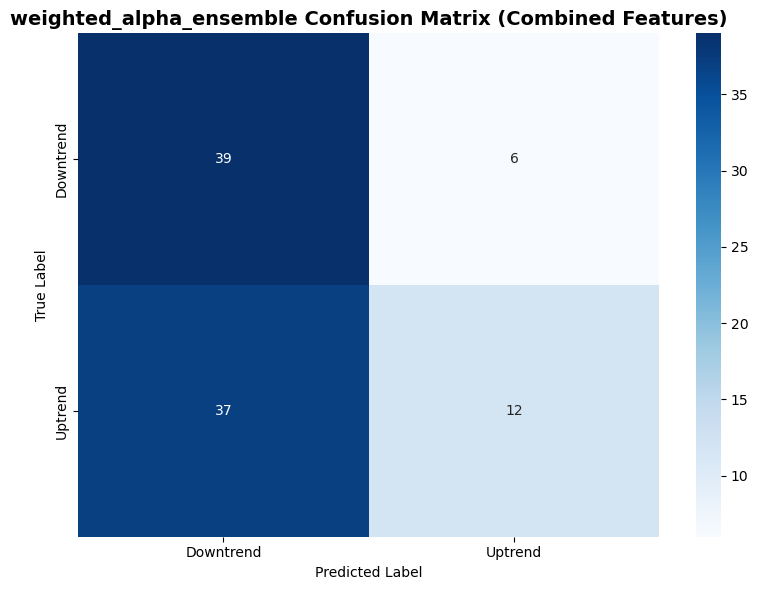

In [70]:
cm = confusion_matrix(y_test_final, y_ens_test, labels=[0, 1])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Downtrend', 'Uptrend'],
            yticklabels=['Downtrend', 'Uptrend'])
plt.title('weighted_alpha_ensemble Confusion Matrix (Combined Features)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()